# Dataset KPI Overview — Helpdesk & BPIC17

Paper-ready statistics for both datasets: case counts, trace lengths,
feature inventories, cardinalities, and event distributions.
Outputs LaTeX-formatted tables.

In [ ]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

In [ ]:
import torch
import numpy as np
import pandas as pd
from collections import Counter, OrderedDict
from IPython.display import display, Markdown

from src.interpretability.utils.tensor_decoder import TensorDecoder

In [ ]:
DATASETS = OrderedDict({
    'Helpdesk': {
        'test': _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl',
        'train': _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_train.pkl',
        'activity_feature': 'Activity',
    },
    'BPIC17': {
        'test': _current / 'encoded_data' / 'BPIC_2017_all_5_test.pkl',
        'train': _current / 'encoded_data' / 'BPIC_2017_all_5_train.pkl',
        'activity_feature': 'concept:name',
    },
})

In [ ]:
def compute_kpis(ds_info):
    """Compute all KPIs for a single dataset."""
    # Load both splits
    splits = {}
    for split_name in ['train', 'test']:
        path = ds_info[split_name]
        if path.exists():
            splits[split_name] = torch.load(str(path), weights_only=False)

    # Use test for structure, combine for counts
    test_ds = splits.get('test') or splits.get('train')
    decoder = TensorDecoder(test_ds)
    act_feat = ds_info['activity_feature']
    act_idx = decoder.cat_features.index(act_feat)
    seq_len = test_ds[0][0][0].shape[0]

    # Unique cases and trace lengths per split
    split_stats = {}
    all_trace_lens = []
    all_event_count = 0

    for split_name, ds in splits.items():
        cases = {}
        for i in range(len(ds)):
            cat_t, _, case_id = ds[i]
            trace_len = int((cat_t[0] != 0).sum().item())
            if case_id not in cases or trace_len > cases[case_id]:
                cases[case_id] = trace_len
        split_stats[split_name] = {
            'n_sequences': len(ds),
            'n_cases': len(cases),
            'trace_lens': list(cases.values()),
        }
        all_trace_lens.extend(cases.values())
        all_event_count += sum(cases.values())

    total_cases = sum(s['n_cases'] for s in split_stats.values())
    total_sequences = sum(s['n_sequences'] for s in split_stats.values())
    lens = np.array(all_trace_lens)

    # Activity distribution (from test set)
    act_counter = Counter()
    eos_idx = None
    for name, idx in decoder.label_to_idx[act_feat].items():
        if name == 'EOS':
            eos_idx = idx
    for i in range(len(test_ds)):
        cat_t = test_ds[i][0][act_idx]
        for v in cat_t:
            vi = v.item()
            if vi != 0 and vi != eos_idx:
                act_counter[decoder.decode_categorical_value(act_feat, vi)] += 1

    # Feature table
    feature_rows = []
    for ci, feat_name in enumerate(decoder.cat_features):
        vocab = decoder.label_to_idx[feat_name]
        # Exclude padding and EOS from count
        real_values = [k for k in vocab.keys() if k not in ('<pad>', 'EOS') and not (isinstance(k, float) and np.isnan(k))]
        feature_rows.append({
            'Feature': feat_name,
            'Type': 'Categorical',
            'Unique Values': len(real_values),
            'Role': 'Encoder + Decoder' if ci < 3 else 'Encoder only',
        })
    for feat_name in decoder.num_features:
        feature_rows.append({
            'Feature': feat_name,
            'Type': 'Numerical',
            'Unique Values': '-',
            'Role': 'Encoder + Decoder' if feat_name in ('case_elapsed_time', 'event_elapsed_time') else 'Encoder only',
        })

    return {
        'total_cases': total_cases,
        'total_sequences': total_sequences,
        'total_events': all_event_count,
        'split_stats': split_stats,
        'trace_len_min': int(lens.min()),
        'trace_len_max': int(lens.max()),
        'trace_len_mean': float(lens.mean()),
        'trace_len_median': float(np.median(lens)),
        'trace_len_std': float(lens.std()),
        'n_activities': len([k for k in decoder.label_to_idx[act_feat] if k not in ('<pad>', 'EOS')]),
        'n_cat_features': len(decoder.cat_features),
        'n_num_features': len(decoder.num_features),
        'max_seq_len': seq_len,
        'suffix_len': test_ds[0][0][0].shape[0] - 1,  # will be overwritten below
        'feature_table': pd.DataFrame(feature_rows),
        'activity_distribution': act_counter,
        'decoder': decoder,
    }

kpis = {}
for name, info in DATASETS.items():
    print(f'Computing KPIs for {name}...')
    kpis[name] = compute_kpis(info)
print('Done.')

Computing KPIs for Helpdesk...


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Computing KPIs for BPIC17...


Done.


## 1. High-level dataset comparison

In [ ]:
rows = []
for ds_name, k in kpis.items():
    rows.append({
        'Dataset': ds_name,
        'Cases (total)': f"{k['total_cases']:,}",
        'Cases (train)': f"{k['split_stats'].get('train', {}).get('n_cases', '-'):,}",
        'Cases (test)': f"{k['split_stats'].get('test', {}).get('n_cases', '-'):,}",
        'Events (total)': f"{k['total_events']:,}",
        'Activities': k['n_activities'],
        'Cat. Features': k['n_cat_features'],
        'Num. Features': k['n_num_features'],
        'Max Seq. Length': k['max_seq_len'],
        'Trace Len (min)': k['trace_len_min'],
        'Trace Len (max)': k['trace_len_max'],
        'Trace Len (mean)': f"{k['trace_len_mean']:.1f}",
        'Trace Len (median)': f"{k['trace_len_median']:.0f}",
    })

df_overview = pd.DataFrame(rows).set_index('Dataset').T
display(df_overview)

# LaTeX
print('\n--- LaTeX (overview) ---')
print(df_overview.to_latex())

Dataset,Helpdesk,BPIC17
Cases (total),"3,893","26,783"
Cases (train),"2,977","20,482"
Cases (test),916,"6,301"
Events (total),"37,624","1,149,864"
Activities,14,26
Cat. Features,12,9
Num. Features,4,9
Max Seq. Length,18,96
Trace Len (min),7,15
Trace Len (max),18,96



--- LaTeX (overview) ---


\begin{tabular}{lll}
\toprule
Dataset & Helpdesk & BPIC17 \\
\midrule
Cases (total) & 3,893 & 26,783 \\
Cases (train) & 2,977 & 20,482 \\
Cases (test) & 916 & 6,301 \\
Events (total) & 37,624 & 1,149,864 \\
Activities & 14 & 26 \\
Cat. Features & 12 & 9 \\
Num. Features & 4 & 9 \\
Max Seq. Length & 18 & 96 \\
Trace Len (min) & 7 & 15 \\
Trace Len (max) & 18 & 96 \\
Trace Len (mean) & 9.7 & 42.9 \\
Trace Len (median) & 9 & 40 \\
\bottomrule
\end{tabular}



## 2. Feature inventory per dataset

In [ ]:
for ds_name, k in kpis.items():
    print(f'\n{"=" * 60}')
    print(f'{ds_name} — Features ({k["n_cat_features"]} categorical, {k["n_num_features"]} numerical)')
    print(f'{"=" * 60}')
    display(k['feature_table'])

    print(f'\n--- LaTeX ({ds_name} features) ---')
    print(k['feature_table'].to_latex(index=False))


Helpdesk — Features (12 categorical, 4 numerical)


,Feature,Type,Unique Values,Role
0,Activity,Categorical,14,Encoder + Decoder
1,Resource,Categorical,22,Encoder + Decoder
2,Variant index,Categorical,173,Encoder + Decoder
3,seriousness,Categorical,1,Encoder only
4,customer,Categorical,359,Encoder only
5,product,Categorical,21,Encoder only
6,responsible_section,Categorical,7,Encoder only
7,seriousness_2,Categorical,4,Encoder only
8,service_level,Categorical,4,Encoder only
9,service_type,Categorical,4,Encoder only



--- LaTeX (Helpdesk features) ---
\begin{tabular}{llll}
\toprule
Feature & Type & Unique Values & Role \\
\midrule
Activity & Categorical & 14 & Encoder + Decoder \\
Resource & Categorical & 22 & Encoder + Decoder \\
Variant index & Categorical & 173 & Encoder + Decoder \\
seriousness & Categorical & 1 & Encoder only \\
customer & Categorical & 359 & Encoder only \\
product & Categorical & 21 & Encoder only \\
responsible_section & Categorical & 7 & Encoder only \\
seriousness_2 & Categorical & 4 & Encoder only \\
service_level & Categorical & 4 & Encoder only \\
service_type & Categorical & 4 & Encoder only \\
support_section & Categorical & 6 & Encoder only \\
workgroup & Categorical & 4 & Encoder only \\
case_elapsed_time & Numerical & - & Encoder + Decoder \\
event_elapsed_time & Numerical & - & Encoder + Decoder \\
day_in_week & Numerical & - & Encoder only \\
seconds_in_day & Numerical & - & Encoder only \\
\bottomrule
\end{tabular}


BPIC17 — Features (9 categorical, 9 numerica

,Feature,Type,Unique Values,Role
0,concept:name,Categorical,26,Encoder + Decoder
1,Action,Categorical,5,Encoder + Decoder
2,org:resource,Categorical,149,Encoder + Decoder
3,EventOrigin,Categorical,3,Encoder only
4,lifecycle:transition,Categorical,7,Encoder only
5,case:LoanGoal,Categorical,14,Encoder only
6,case:ApplicationType,Categorical,2,Encoder only
7,Accepted,Categorical,2,Encoder only
8,Selected,Categorical,2,Encoder only
9,case_elapsed_time,Numerical,-,Encoder + Decoder



--- LaTeX (BPIC17 features) ---
\begin{tabular}{llll}
\toprule
Feature & Type & Unique Values & Role \\
\midrule
concept:name & Categorical & 26 & Encoder + Decoder \\
Action & Categorical & 5 & Encoder + Decoder \\
org:resource & Categorical & 149 & Encoder + Decoder \\
EventOrigin & Categorical & 3 & Encoder only \\
lifecycle:transition & Categorical & 7 & Encoder only \\
case:LoanGoal & Categorical & 14 & Encoder only \\
case:ApplicationType & Categorical & 2 & Encoder only \\
Accepted & Categorical & 2 & Encoder only \\
Selected & Categorical & 2 & Encoder only \\
case_elapsed_time & Numerical & - & Encoder + Decoder \\
event_elapsed_time & Numerical & - & Encoder + Decoder \\
day_in_week & Numerical & - & Encoder only \\
seconds_in_day & Numerical & - & Encoder only \\
case:RequestedAmount & Numerical & - & Encoder only \\
FirstWithdrawalAmount & Numerical & - & Encoder only \\
NumberOfTerms & Numerical & - & Encoder only \\
MonthlyCost & Numerical & - & Encoder only \\
CreditSco

## 3. Activity distribution per dataset


Helpdesk — Activity Distribution (13 activities, 28,905 events)


,Activity,Count,Proportion
0,Take in charge ticket,6983,24.2%
1,Assign seriousness,6737,23.3%
2,Resolve ticket,6542,22.6%
3,Closed,5825,20.2%
4,Wait,2278,7.9%
5,Insert ticket,213,0.7%
6,Require upgrade,168,0.6%
7,Create SW anomaly,101,0.3%
8,Resolve SW anomaly,21,0.1%
9,Schedule intervention,10,0.0%


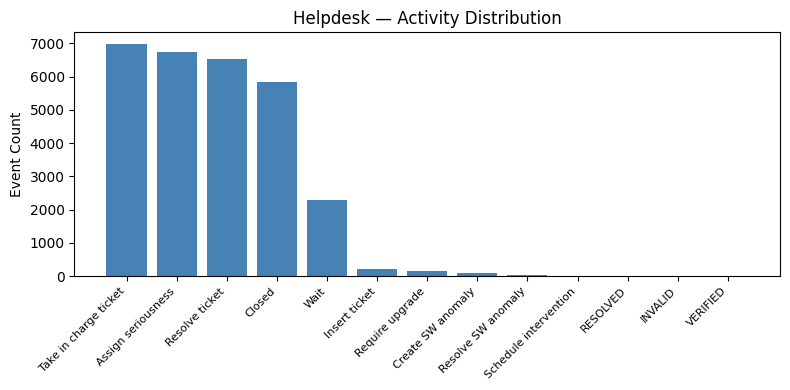

--- LaTeX (Helpdesk activities) ---
\begin{tabular}{lrl}
\toprule
Activity & Count & Proportion \\
\midrule
Take in charge ticket & 6983 & 24.2% \\
Assign seriousness & 6737 & 23.3% \\
Resolve ticket & 6542 & 22.6% \\
Closed & 5825 & 20.2% \\
Wait & 2278 & 7.9% \\
Insert ticket & 213 & 0.7% \\
Require upgrade & 168 & 0.6% \\
Create SW anomaly & 101 & 0.3% \\
Resolve SW anomaly & 21 & 0.1% \\
Schedule intervention & 10 & 0.0% \\
RESOLVED & 10 & 0.0% \\
INVALID & 9 & 0.0% \\
VERIFIED & 8 & 0.0% \\
\bottomrule
\end{tabular}


BPIC17 — Activity Distribution (25 activities, 6,975,720 events)


,Activity,Count,Proportion
0,W_Complete application,1132412,16.2%
1,W_Call after offers,1054146,15.1%
2,W_Validate application,1005438,14.4%
3,W_Call incomplete files,858683,12.3%
4,W_Handle leads,388822,5.6%
5,O_Create Offer,302708,4.3%
6,O_Created,294114,4.2%
7,O_Sent (mail and online),261023,3.7%
8,A_Create Application,251907,3.6%
9,A_Concept,246232,3.5%


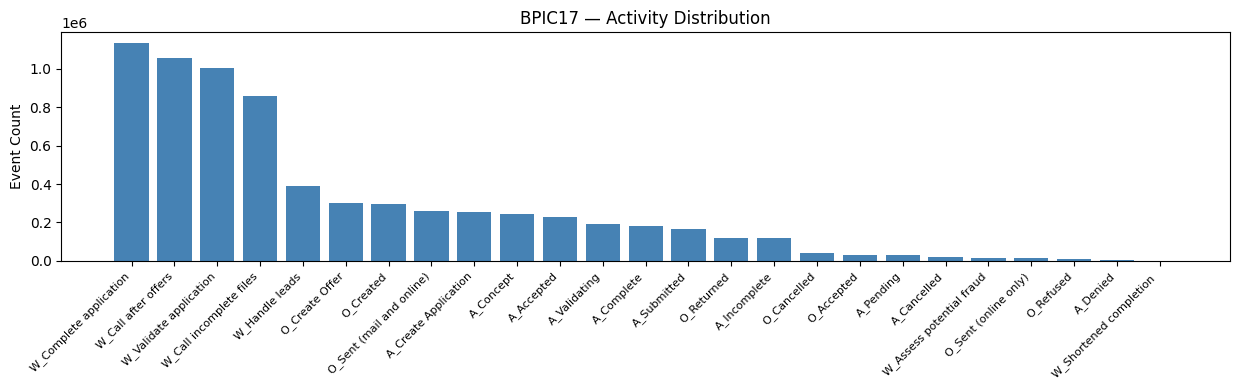

--- LaTeX (BPIC17 activities) ---
\begin{tabular}{lrl}
\toprule
Activity & Count & Proportion \\
\midrule
W_Complete application & 1132412 & 16.2% \\
W_Call after offers & 1054146 & 15.1% \\
W_Validate application & 1005438 & 14.4% \\
W_Call incomplete files & 858683 & 12.3% \\
W_Handle leads & 388822 & 5.6% \\
O_Create Offer & 302708 & 4.3% \\
O_Created & 294114 & 4.2% \\
O_Sent (mail and online) & 261023 & 3.7% \\
A_Create Application & 251907 & 3.6% \\
A_Concept & 246232 & 3.5% \\
A_Accepted & 229340 & 3.3% \\
A_Validating & 192997 & 2.8% \\
A_Complete & 181687 & 2.6% \\
A_Submitted & 166018 & 2.4% \\
O_Returned & 120358 & 1.7% \\
A_Incomplete & 118817 & 1.7% \\
O_Cancelled & 43534 & 0.6% \\
O_Accepted & 31828 & 0.5% \\
A_Pending & 28422 & 0.4% \\
A_Cancelled & 19625 & 0.3% \\
W_Assess potential fraud & 17428 & 0.2% \\
O_Sent (online only) & 13366 & 0.2% \\
O_Refused & 7866 & 0.1% \\
A_Denied & 6990 & 0.1% \\
W_Shortened completion  & 1959 & 0.0% \\
\bottomrule
\end{tabular}



In [ ]:
import matplotlib.pyplot as plt

for ds_name, k in kpis.items():
    act_dist = k['activity_distribution']
    total = sum(act_dist.values())

    df_act = pd.DataFrame([
        {'Activity': act, 'Count': cnt, 'Proportion': f'{cnt/total*100:.1f}%'}
        for act, cnt in act_dist.most_common()
    ])

    print(f'\n{"=" * 60}')
    print(f'{ds_name} — Activity Distribution ({len(act_dist)} activities, {total:,} events)')
    print(f'{"=" * 60}')
    display(df_act)

    fig, ax = plt.subplots(figsize=(max(8, len(act_dist) * 0.5), 4))
    bars = ax.bar(range(len(df_act)), df_act['Count'], color='steelblue')
    ax.set_xticks(range(len(df_act)))
    ax.set_xticklabels(df_act['Activity'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Event Count')
    ax.set_title(f'{ds_name} — Activity Distribution')
    plt.tight_layout()
    plt.show()

    print(f'--- LaTeX ({ds_name} activities) ---')
    print(df_act.to_latex(index=False))

## 4. Trace length distribution

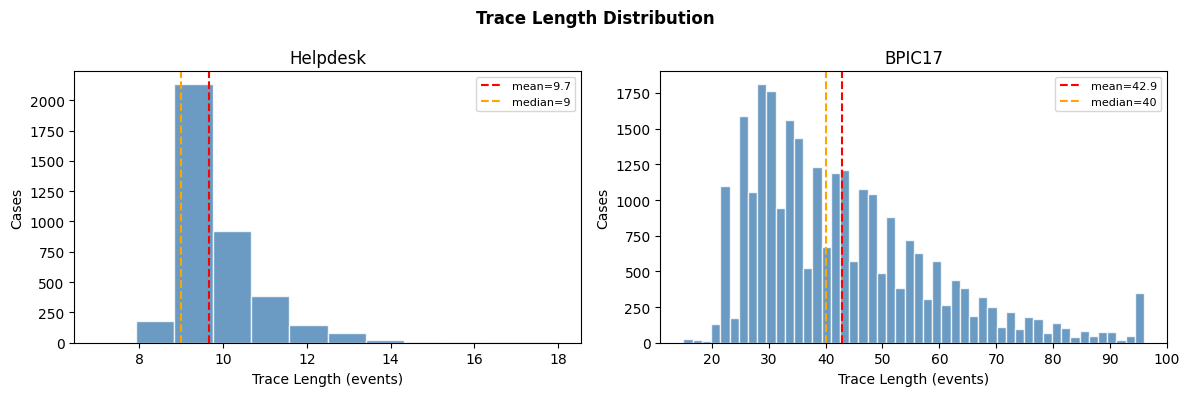

In [ ]:
fig, axes = plt.subplots(1, len(kpis), figsize=(6 * len(kpis), 4))
if len(kpis) == 1:
    axes = [axes]

for ax, (ds_name, k) in zip(axes, kpis.items()):
    all_lens = []
    for split in k['split_stats'].values():
        all_lens.extend(split['trace_lens'])
    ax.hist(all_lens, bins=min(50, max(all_lens) - min(all_lens) + 1),
            color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(all_lens), color='red', linestyle='--', label=f'mean={np.mean(all_lens):.1f}')
    ax.axvline(np.median(all_lens), color='orange', linestyle='--', label=f'median={np.median(all_lens):.0f}')
    ax.set_xlabel('Trace Length (events)')
    ax.set_ylabel('Cases')
    ax.set_title(f'{ds_name}')
    ax.legend(fontsize=8)

plt.suptitle('Trace Length Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Combined summary table (paper-ready)

In [ ]:
# Compact table suitable for a paper
summary_rows = []
for ds_name, k in kpis.items():
    summary_rows.append({
        'Dataset': ds_name,
        'Cases': f"{k['total_cases']:,}",
        'Events': f"{k['total_events']:,}",
        'Activities': k['n_activities'],
        'Features (cat/num)': f"{k['n_cat_features']}/{k['n_num_features']}",
        'Trace length': f"{k['trace_len_min']}--{k['trace_len_max']} (avg {k['trace_len_mean']:.1f})",
        'Max seq. length': k['max_seq_len'],
    })

df_summary = pd.DataFrame(summary_rows).set_index('Dataset')
display(df_summary)

print('\n--- LaTeX (compact summary) ---')
print(df_summary.to_latex())

,Cases,Events,Activities,Features (cat/num),Trace length,Max seq. length
Dataset,,,,,,
Helpdesk,"3,893","37,624",14,12/4,7--18 (avg 9.7),18
BPIC17,"26,783","1,149,864",26,9/9,15--96 (avg 42.9),96



--- LaTeX (compact summary) ---
\begin{tabular}{lllrllr}
\toprule
 & Cases & Events & Activities & Features (cat/num) & Trace length & Max seq. length \\
Dataset &  &  &  &  &  &  \\
\midrule
Helpdesk & 3,893 & 37,624 & 14 & 12/4 & 7--18 (avg 9.7) & 18 \\
BPIC17 & 26,783 & 1,149,864 & 26 & 9/9 & 15--96 (avg 42.9) & 96 \\
\bottomrule
\end{tabular}

